<a href="https://colab.research.google.com/github/kajall120/Data_science_Lab_SE_64/blob/main/experiment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [3]:
import zipfile
with zipfile.ZipFile("/content/ml-latest-small.zip") as zip_ref:
  zip_ref.extractall("data")



In [4]:
ratings = pd.read_csv("data/ml-latest-small/ratings.csv")
movies = pd.read_csv("data/ml-latest-small/movies.csv")

data = pd.merge(ratings, movies, on="movieId")

data.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [5]:
print(data.shape)
print(data.columns)
print(data.isnull().sum())

(100836, 6)
Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


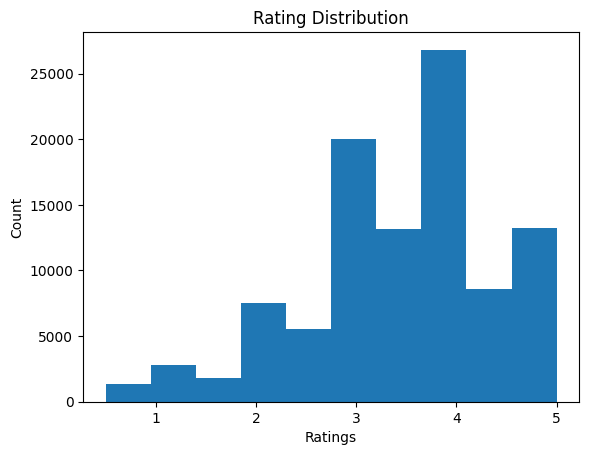

In [6]:


plt.hist(data['rating'])
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [7]:
data['genres'] = data['genres'].astype('category').cat.codes

X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

In [9]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

In [10]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.9645704271513545


In [11]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

In [12]:
y_cls = data['rating_class']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

In [14]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print(classification_report(y_test, y_pred_cls))

Accuracy: 0.6590638635462118
              precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.66     20168



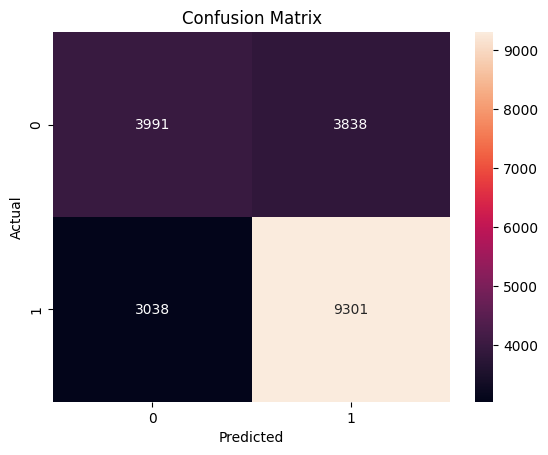

In [16]:
cm = confusion_matrix(y_test, y_pred_cls)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()